### Lab 10
### 10.4 Principal Components Analysis

Original features
['Murder', 'Assault', 'UrbanPop', 'Rape']

Feature Means
Murder        7.79
Assault     170.76
UrbanPop     65.54
Rape         21.23
dtype: float64

Feature Variances
Murder        19.0
Assault     6945.2
UrbanPop     209.5
Rape          87.7
dtype: float64

Loading matix (Loadings / Rotation) ---
            PC1    PC2    PC3    PC4
Murder   -0.536  0.418  0.341  0.649
Assault  -0.583  0.188  0.268 -0.743
UrbanPop -0.278 -0.873  0.378  0.134
Rape     -0.543 -0.167 -0.818  0.089

Scores Matrix Shape
(50, 4)

Stadnard deviation components (sdev)
[1.591 1.005 0.603 0.421]

Portion PVE
PC1: 62.01%
PC2: 24.74%
PC3: 8.91%
PC4: 4.34%


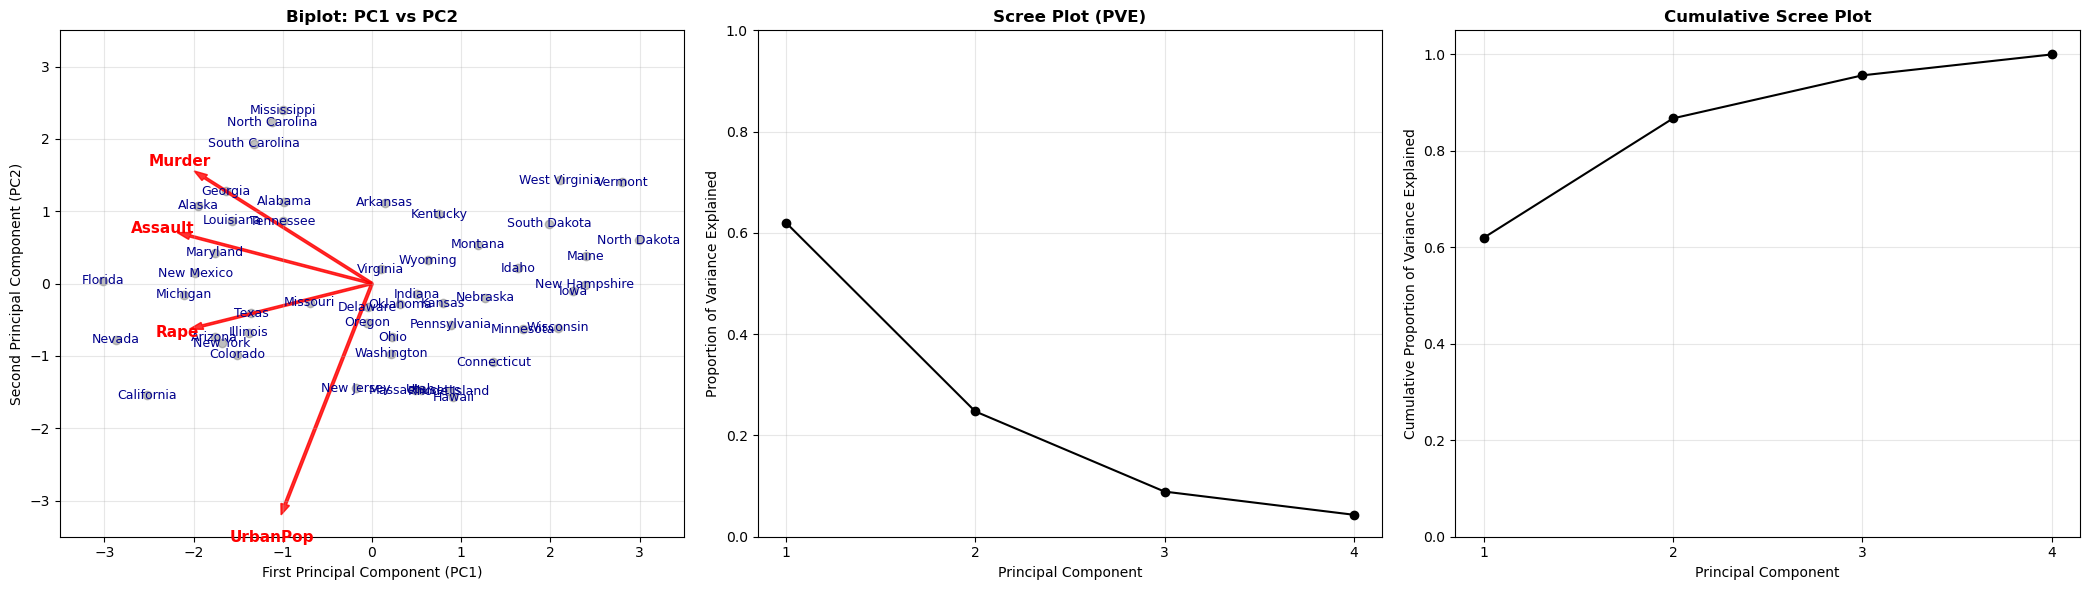

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load data USArrests
df = pd.read_csv("data/USArrests.csv", index_col=0)

print("Original features")
print(df.columns.tolist())

print("\nFeature Means")
print(df.mean().round(2))

print("\nFeature Variances")
print(df.var().round(1))

# 2. Standardizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

loadings = -pca.components_.T
scores = -X_pca

components_names = [f'PC{i+1}' for i in range(pca.n_components_)]
df_loadings = pd.DataFrame(loadings, index=df.columns, columns=components_names)
df_scores = pd.DataFrame(scores, index=df.index, columns=components_names)

print("\nLoading matix (Loadings / Rotation) ---")
print(df_loadings.round(3))

print("\nScores Matrix Shape")
print(df_scores.shape)

# 3. PVE
sdev = np.sqrt(pca.explained_variance_)
print("\nStadnard deviation components (sdev)")
print(np.round(sdev, 3))

pve = pca.explained_variance_ratio_
print("\nPortion PVE")
for i, val in enumerate(pve, start=1):
    print(f"PC{i}: {val:.2%}")

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

ax1 = axes[0]
ax1.scatter(df_scores["PC1"], df_scores["PC2"], color="gray", alpha=0.5)
for state in df_scores.index:
    ax1.text(df_scores.loc[state, "PC1"], df_scores.loc[state, "PC2"], state, 
             fontsize=9, ha="center", va="center", color="darkblue")

scale_factor = 3.5
for feature in df_loadings.index:
    ax1.arrow(0, 0, df_loadings.loc[feature, "PC1"] * scale_factor, 
              df_loadings.loc[feature, "PC2"] * scale_factor, 
              color='red', width=0.03, head_width=0.1, alpha=0.8)
    ax1.text(df_loadings.loc[feature, "PC1"] * scale_factor * 1.15, 
             df_loadings.loc[feature, "PC2"] * scale_factor * 1.15, 
             feature, color='red', fontsize=11, weight="bold", ha="center", va="center")

ax1.set_xlabel("First Principal Component (PC1)")
ax1.set_ylabel("Second Principal Component (PC2)")
ax1.set_title("Biplot: PC1 vs PC2", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-3.5, 3.5)
ax1.set_ylim(-3.5, 3.5)
# График 2: Scree Plot (PVE)
ax2 = axes[1]
ax2.plot(range(1, 5), pve, marker='o', linestyle='-', color='black')
ax2.set_xlabel('Principal Component')
ax2.set_ylabel('Proportion of Variance Explained')
ax2.set_title('Scree Plot (PVE)', fontsize=12, fontweight='bold')
ax2.set_xticks(range(1, 5))
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
ax3.plot(range(1, 5), np.cumsum(pve), marker='o', linestyle='-', color="black")
ax3.set_xlabel("Principal Component")
ax3.set_ylabel("Cumulative Proportion of Variance Explained")
ax3.set_title("Cumulative Scree Plot", fontsize=12, fontweight="bold")
ax3.set_xticks(range(1, 5))
ax3.set_ylim(0, 1.05)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

First Principal Component: Explains 62.01% of the total variance. It is heavily and almost equally weighted by crime-related variables: Assault (-0.583), Rape (-0.543), and Murder (-0.536). Since all these loadings are negative, PC1 effectively serves as a general index of overall crime rates, where lower (more negative) scores represent states with significantly higher crime levels

Second Principal Component (PC2): Explains 24.74% of the variance. It is overwhelmingly dominated by the UrbanPop variable with a strong negative loading of -0.873. Therefore, PC2 predominantly captures the level of urbanization of a state, with more negative scores indicating highly urbanized areas

When analyzing the biplot, observations must be interpreted in relation to the direction of the feature loading vectors (arrows):

- High Crime States: States located on the far left of the plot, such as California, Nevada, and Florida, align with the crime vectors and thus possess the highest crime rates per 100,000 residents.

- Low Crime States: Conversely, states on the far right, like North Dakota, South Dakota, and Iowa, have high positive PC1 scores, indicating very low rates of violent crime.
